<a href="https://colab.research.google.com/github/Briyad37/Rwanda-youth-employment-skills-gap/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Analysis Notebook

In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We get the cleaned Dataset

In [3]:
path = "/content/drive/MyDrive/Rwanda-youth-employment-skills-gap"
youth= pd.read_csv("/content/drive/MyDrive/Rwanda-youth-employment-skills-gap/Data/cleaned_labour_force_by_youth_adult.csv")

In [4]:
youth

,age_group,year,quarter,employment_to_population_ratio,lf_participation_rate,lu1_unemployment_rate,lu2_unemployment_underemployment_rate,lu3_unemployment_potential_lf_rate,lu4_labour_underutilization_rate,median_monthly_earnings,youth_neet_rate,out_of_lf_inactivity_rate,time_underemployment_rate
0,Adult,2019,Q1,48.331897,54.232306,10.879878,35.645545,36.495948,54.143143,24000.0,NaN,45.767694,27.789086
1,Adult,2019,Q2,48.929103,55.945526,12.541526,35.608738,36.854824,53.509393,26000.0,NaN,44.054474,26.375046
2,Adult,2019,Q3,47.259101,53.953333,12.407450,35.794088,38.638449,55.021582,26000.0,NaN,46.046667,26.699346
3,Adult,2019,Q4,49.805675,56.691319,12.145853,34.915767,35.788924,52.431060,26000.0,NaN,43.308681,25.917859
4,Adult,2020,Q1,51.932353,57.598108,9.836704,37.669036,34.140010,54.470202,26000.0,NaN,42.401892,30.868805
5,Adult,2020,Q2,46.757345,56.799070,17.679382,0.000000,17.679382,NaN,NaN,NaN,43.200930,0.000000
6,Adult,2020,Q3,51.009718,57.981579,12.024267,35.642713,35.681362,52.948695,26000.0,NaN,42.018421,26.846546
7,Adult,2020,Q4,48.202467,57.955786,16.828896,42.843337,37.933932,57.347093,26000.0,NaN,42.044214,31.278220
8,Adult,2021,Q1,46.979930,54.422834,13.676068,40.768066,36.134412,56.178059,26000.0,NaN,45.577166,31.384111
9,Adult,2021,Q2,44.299872,55.350819,19.965281,43.851995,40.402504,58.189639,26000.0,NaN,44.649181,29.845440


Employment Rate over the years


In [5]:
#groupby burigihe ihita ihindura ama columns wayihaye the index columns so we use reset_index() to reset them to normal

yearly_avg= youth.groupby(["year","age_group"])["employment_to_population_ratio"].mean().reset_index()

In [6]:
yearly_avg

,year,age_group,employment_to_population_ratio
0,2019,Adult,48.581444
1,2019,Youth,41.255657
2,2020,Adult,49.475471
3,2020,Youth,42.682578
4,2021,Adult,47.294354
5,2021,Youth,36.951870
6,2022,Adult,49.689816
7,2022,Youth,38.156356
8,2023,Adult,52.522217
9,2023,Youth,44.463199


In [51]:
#now we create df for line bar
line_data= yearly_avg.pivot(
    index="year",
    columns="age_group",
    values="employment_to_population_ratio"
)

#I add a column to show employment difference from the two groups
line_data["employment_rate_difference"]= line_data["Adult"] - line_data["Youth"]

In [52]:
line_data

age_group,Adult,Youth,employment_rate_difference
year,,,
2019,48.581444,41.255657,7.325787
2020,49.475471,42.682578,6.792893
2021,47.294354,36.951870,10.342484
2022,49.689816,38.156356,11.533460
2023,52.522217,44.463199,8.059018
2024,56.806726,49.370224,7.436502
2025,58.721663,52.109175,6.612488


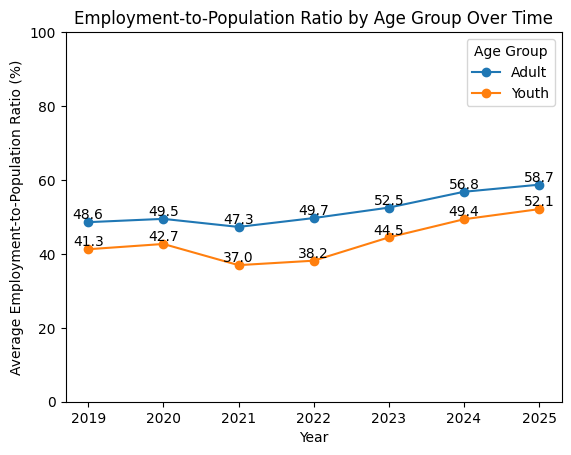

In [49]:
#Now we create a plot for the above created df
line_chart=line_data.plot(kind="line", marker="o")

#iyi ni loop ituma buri data igira label of values!
for line in line_chart.lines:
  for x,y in zip(line.get_xdata(),line.get_ydata()):
    line_chart.text(x,y,f"{y:.1f}",ha="center",va="bottom")



plt.title("Employment-to-Population Ratio by Age Group Over Time")
plt.xlabel("Year")
plt.ylabel("Average Employment-to-Population Ratio (%)")
plt.legend(title="Age Group")
plt.ylim(bottom=0, top=100) #this is tomake y axis start from 0 and end at 100
plt.show()

1.As we can see from the above line chart, overtime employment in both Adullts and the Youth have increased but It is also clear that It was always higher in Adults than Youth.

2. 2022 has been the year where there was the biggest difference in employment rate with adult employment being 11% more than youth employment rate!

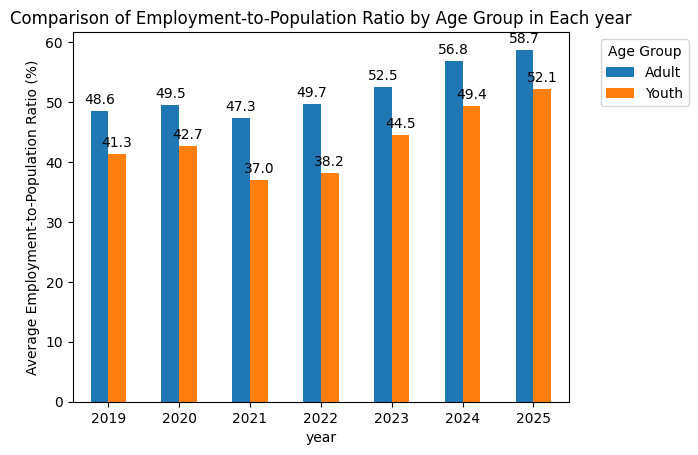

In [43]:
bar_plot=line_data.plot(kind="bar")

#Iyi ni label ifasha gushyira ama labels ku ma bars
for container in bar_plot.containers:
  bar_plot.bar_label(container, fmt="%.1f", padding=3, label_type="edge")

plt.title("Comparison of Employment-to-Population Ratio by Age Group in Each year")
plt.xlabel("year")
plt.ylabel("Average Employment-to-Population Ratio (%)")
plt.legend(title="Age Group",bbox_to_anchor=(1.05, 1)) #decides where legend appear
plt.xticks(rotation=0) #makes categories on x-aaaaxis not come rotated
plt.show()

The above column chart Complies with the information that from 2019-2025, employment in adults have been higher than in youth in each year.